# Job Market Demand - Data Exploration

This notebook explores the three datasets:
- **company.parquet**: Job postings data
- **region.parquet**: Regional labor market data
- **r0.parquet**: Unknown dataset (to be discovered)

Goal: Understand the structure, quality, and content of each dataset before building models.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets

In [8]:
# Define dataset paths
datasets_dir = Path('datasets')

company_path = datasets_dir / 'company.parquet'
region_path = datasets_dir / 'region.parquet'
r0_path = datasets_dir / 'r0.parquet'

# Load datasets
print("Loading datasets...")
df_company = pd.read_parquet(company_path, engine="fastparquet")
df_region = pd.read_parquet(region_path, engine="fastparquet")
df_r0 = pd.read_parquet(r0_path, engine="fastparquet")

print("✓ All datasets loaded successfully!")
print(f"- company.parquet: {df_company.shape[0]} rows, {df_company.shape[1]} columns")
print(f"- region.parquet: {df_region.shape[0]} rows, {df_region.shape[1]} columns")
print(f"- r0.parquet: {df_r0.shape[0]} rows, {df_r0.shape[1]} columns")

Loading datasets...
✓ All datasets loaded successfully!
- company.parquet: 1216535 rows, 38 columns
- region.parquet: 16345 rows, 38 columns
- r0.parquet: 2335 rows, 38 columns


In [ ]:
import pyarrow.parquet as pq

print("\n=== PARQUET METADATA INSPECTION ===")
for path, label in [(company_path, 'company'), (region_path, 'region'), (r0_path, 'r0')]:
    pf = pq.ParquetFile(path)
    print(f"\n{label}.parquet")
    print(f"  rows: {pf.metadata.num_rows}")
    print(f"  columns: {len(pf.schema.names)}")
    print(f"  schema: {pf.schema}")
    print(f"  row groups: {pf.num_row_groups}")
    print("  compression by column:")
    for col in pf.metadata.row_group(0).column_metadata:
        print(f"    {col.path_in_schema}: {col.compression}\n      encodings: {list(col.encodings)}")

print("\n=== CATEGORICAL / ENCODING HINTS ===")
for df, label, cat_cols in [
    (df_company, 'company', ['company_id', 'skill_id']),
    (df_region, 'region', ['company_id', 'skill_id']),
    (df_r0, 'r0', ['r0_id', 'skill_id'])
]:
    print(f"\n{label} dataset")
    for col in cat_cols:
        if col in df.columns:
            unique_count = df[col].nunique(dropna=False)
            sample = df[col].dropna().unique()[:10]
            print(f"  {col}: unique values = {unique_count}, sample = {sample}")

print("\n=== QUICK VALUE CHECK ===")
for col in ['company_id', 'skill_id', 'r0_id']:
    if col in df_company.columns:
        print(f"\ncompany[{col}] head:\n", df_company[col].head(10).tolist())
    if col in df_r0.columns:
        print(f"\nr0[{col}] head:\n", df_r0[col].head(10).tolist())
</VSCode.Cell>


In [5]:
import pyarrow
print(pyarrow.__version__)

24.0.0


## 3. Explore company.parquet Dataset

### Schema and Data Types

In [9]:
print("=" * 60)
print("COMPANY DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_company.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_company.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_company.columns, 1):
    print(f"{i}. {col}")

COMPANY DATASET ANALYSIS

Data Types:
company_id      int64
skill_id        int64
2021-01       float64
2021-02       float64
2021-03       float64
2021-04       float64
2021-05       float64
2021-06       float64
2021-07       float64
2021-08       float64
2021-09       float64
2021-10       float64
2021-11       float64
2021-12       float64
2022-01       float64
2022-02       float64
2022-03       float64
2022-04       float64
2022-05       float64
2022-06       float64
2022-07       float64
2022-08       float64
2022-09       float64
2022-10       float64
2022-11       float64
2022-12       float64
2023-01       float64
2023-02       float64
2023-03       float64
2023-04       float64
2023-05       float64
2023-06       float64
2023-07       float64
2023-08       float64
2023-09       float64
2023-10       float64
2023-11       float64
2023-12       float64
dtype: object

First 5 Rows:
   company_id  skill_id  2021-01  2021-02  2021-03  2021-04  2021-05  2021-06  \
0           0   

In [10]:
print("\nMissing Values:")
missing = df_company.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_company.describe(include='all'))


Missing Values:
✓ No missing values!

Basic Statistics:
         company_id      skill_id       2021-01       2021-02       2021-03  \
count  1.216535e+06  1.216535e+06  1.216535e+06  1.216535e+06  1.216535e+06   
mean   2.600000e+02  1.167000e+03  1.048002e+00  8.133009e-01  1.697710e+00   
std    1.503995e+02  6.740567e+02  1.441134e+01  9.362123e+00  1.790238e+01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.300000e+02  5.830000e+02  0.000000e+00  0.000000e+00  0.000000e+00   
50%    2.600000e+02  1.167000e+03  0.000000e+00  0.000000e+00  0.000000e+00   
75%    3.900000e+02  1.751000e+03  0.000000e+00  0.000000e+00  0.000000e+00   
max    5.200000e+02  2.334000e+03  3.511000e+03  2.126000e+03  3.099000e+03   

            2021-04       2021-05       2021-06       2021-07       2021-08  \
count  1.216535e+06  1.216535e+06  1.216535e+06  1.216535e+06  1.216535e+06   
mean   1.712131e+00  1.615186e+00  1.968865e+00  2.148865e+00  2.174930e+

## 4. Explore region.parquet Dataset

In [11]:
print("=" * 60)
print("REGION DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_region.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_region.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_region.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values:")
missing = df_region.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_region.describe(include='all'))

REGION DATASET ANALYSIS

Data Types:
region_id      int64
skill_id       int64
2021-01      float64
2021-02      float64
2021-03      float64
2021-04      float64
2021-05      float64
2021-06      float64
2021-07      float64
2021-08      float64
2021-09      float64
2021-10      float64
2021-11      float64
2021-12      float64
2022-01      float64
2022-02      float64
2022-03      float64
2022-04      float64
2022-05      float64
2022-06      float64
2022-07      float64
2022-08      float64
2022-09      float64
2022-10      float64
2022-11      float64
2022-12      float64
2023-01      float64
2023-02      float64
2023-03      float64
2023-04      float64
2023-05      float64
2023-06      float64
2023-07      float64
2023-08      float64
2023-09      float64
2023-10      float64
2023-11      float64
2023-12      float64
dtype: object

First 5 Rows:
   region_id  skill_id  2021-01  2021-02  2021-03  2021-04  2021-05  2021-06  \
0          0         0      1.0      0.0      5.0      0

## 5. Explore r0.parquet Dataset

In [17]:
print("=" * 60)
print("R0 DATASET ANALYSIS")
print("=" * 60)
print("\nData Types:")
print(df_r0.dtypes)
print("\n" + "=" * 60)
print("First 5 Rows:")
print(df_r0.head())
print("\n" + "=" * 60)
print("Column Names:")
for i, col in enumerate(df_r0.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values:")
missing = df_r0.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])

print("\nBasic Statistics:")
print(df_r0.describe(include='all'))

R0 DATASET ANALYSIS

Data Types:
r0_id         int64
skill_id      int64
2021-01     float64
2021-02     float64
2021-03     float64
2021-04     float64
2021-05     float64
2021-06     float64
2021-07     float64
2021-08     float64
2021-09     float64
2021-10     float64
2021-11     float64
2021-12     float64
2022-01     float64
2022-02     float64
2022-03     float64
2022-04     float64
2022-05     float64
2022-06     float64
2022-07     float64
2022-08     float64
2022-09     float64
2022-10     float64
2022-11     float64
2022-12     float64
2023-01     float64
2023-02     float64
2023-03     float64
2023-04     float64
2023-05     float64
2023-06     float64
2023-07     float64
2023-08     float64
2023-09     float64
2023-10     float64
2023-11     float64
2023-12     float64
dtype: object

First 5 Rows:
   r0_id  skill_id  2021-01  2021-02  2021-03  2021-04  2021-05  2021-06  \
0      0         0     63.0     73.0    135.0    109.0     82.0    117.0   
1      0         1      1.

## 6. Summary & Key Findings

In [13]:
print("\n" + "=" * 60)
print("SUMMARY OF DATASETS")
print("=" * 60)

summary = pd.DataFrame({
    'Dataset': ['company', 'region', 'r0'],
    'Rows': [len(df_company), len(df_region), len(df_r0)],
    'Columns': [len(df_company.columns), len(df_region.columns), len(df_r0.columns)],
    'Missing Values': [df_company.isnull().sum().sum(), df_region.isnull().sum().sum(), df_r0.isnull().sum().sum()],
    'Data Types': [
        f"Numeric: {(df_company.dtypes == 'int64').sum() + (df_company.dtypes == 'float64').sum()}, Object: {(df_company.dtypes == 'object').sum()}",
        f"Numeric: {(df_region.dtypes == 'int64').sum() + (df_region.dtypes == 'float64').sum()}, Object: {(df_region.dtypes == 'object').sum()}",
        f"Numeric: {(df_r0.dtypes == 'int64').sum() + (df_r0.dtypes == 'float64').sum()}, Object: {(df_r0.dtypes == 'object').sum()}"
    ]
})

print("\n")
print(summary.to_string(index=False))
print("\n" + "=" * 60)
print("Next Steps:")
print("1. Review the schema of each dataset above")
print("2. Check for salary data and skill information")
print("3. Plan data cleaning strategy")
print("4. Design feature engineering approach")
print("=" * 60)


SUMMARY OF DATASETS


Dataset    Rows  Columns  Missing Values             Data Types
company 1216535       38               0 Numeric: 38, Object: 0
 region   16345       38               0 Numeric: 38, Object: 0
     r0    2335       38               0 Numeric: 38, Object: 0

Next Steps:
1. Review the schema of each dataset above
2. Check for salary data and skill information
3. Plan data cleaning strategy
4. Design feature engineering approach


## 7. Entity Encoding/Decoding Method from Benchmark

This section demonstrates the encoding scheme used in the Job-SDF benchmark repository.

**Key Concepts:**
- Multi-dimensional entities (e.g., company_id + region_id) are encoded into single integers
- Skill IDs are offset by 200,000 to distinguish them from other entity types
- Formula: `encoded_id = dimension_0 + dimension_1 * card[0] + dimension_2 * card[0] * card[1] + ...`


In [ ]:
# Import the encoding module
import sys
sys.path.insert(0, '.')
from entity_encoding import EntityEncoder, encode_multi_dimensional_entity, decode_multi_dimensional_entity

# Get cardinalities from the data
print("Analyzing entity cardinalities...")
print("=" * 60)

# For company dataset
company_cardinality = df_company['company_id'].max() + 1
skill_cardinality_company = df_company['skill_id'].max() + 1

# For region dataset
region_cardinality = df_region['region_id'].max() + 1 if 'region_id' in df_region.columns else 0
skill_cardinality_region = df_region['skill_id'].max() + 1

# For r0 dataset
r0_cardinality = df_r0['r0_id'].max() + 1 if 'r0_id' in df_r0.columns else 0
skill_cardinality_r0 = df_r0['skill_id'].max() + 1

print(f"Company cardinality: {company_cardinality}")
print(f"Skill cardinality (company): {skill_cardinality_company}")
print(f"Region cardinality: {region_cardinality}")
print(f"R0 cardinality: {r0_cardinality}")

# Example: Encoding a company entity
print("\n" + "=" * 60)
print("Example: Encoding Multi-Dimensional Entity")
print("=" * 60)

# If there are companies and skills in the data
if len(df_company) > 0:
    sample_company_id = df_company.iloc[0]['company_id']
    sample_skill_id = df_company.iloc[0]['skill_id']
    
    print(f"\nSample company_id: {sample_company_id}")
    print(f"Sample skill_id: {sample_skill_id}")
    
    # Encode the pair
    encoded = encode_multi_dimensional_entity(
        [sample_company_id, sample_skill_id],
        [company_cardinality, skill_cardinality_company]
    )
    print(f"Encoded (company + skill): {encoded}")
    
    # Decode it back
    decoded = decode_multi_dimensional_entity(
        encoded,
        [company_cardinality, skill_cardinality_company]
    )
    print(f"Decoded: company_id={decoded[0]}, skill_id={decoded[1]}")
    print(f"Match: {decoded[0] == sample_company_id and decoded[1] == sample_skill_id}")

print("\n" + "=" * 60)
print("Encoding Scheme Summary:")
print("=" * 60)
print("""
Formula: encoded_id = id_0 + id_1 * card[0] + id_2 * card[0] * card[1] + ...

Where:
  - id_i: Value of dimension i
  - card[i]: Cardinality (max value) of dimension i
  
Skill Offset: Skill IDs are offset by 200,000 in the benchmark
""")


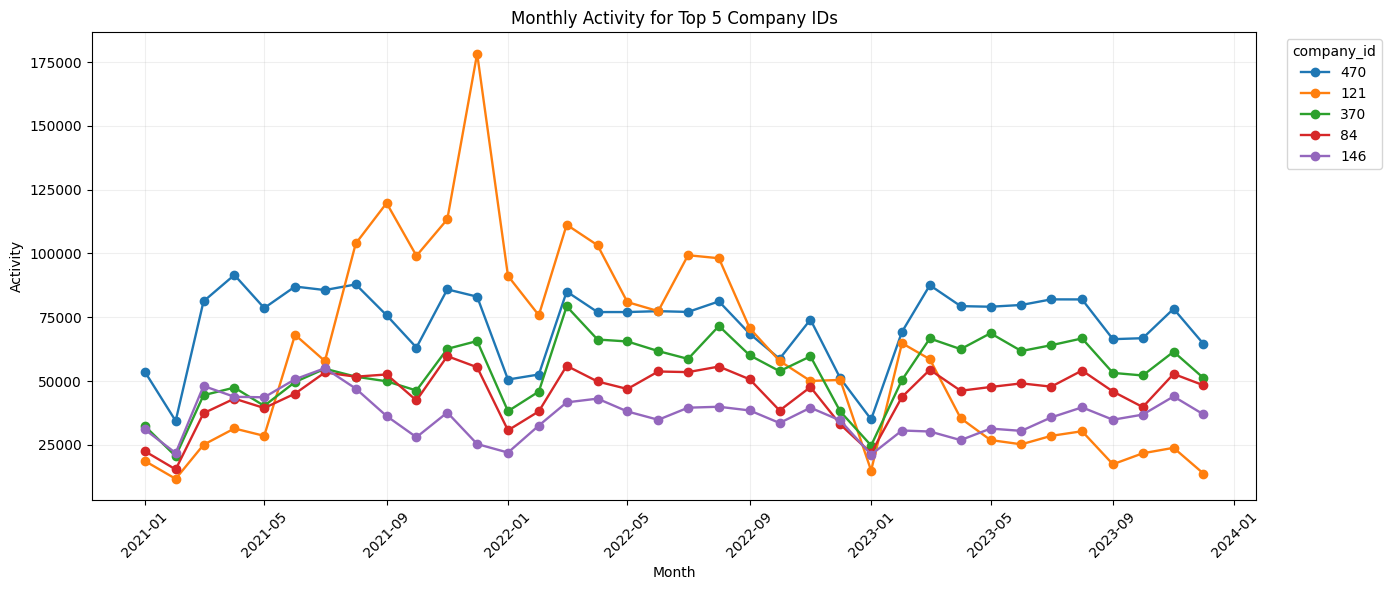

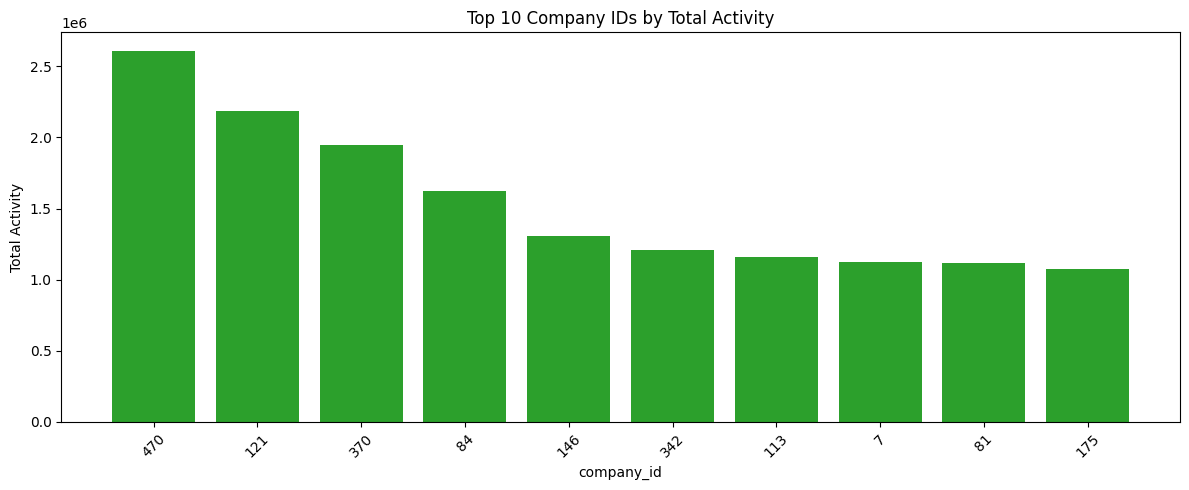

In [18]:
# Differentiate company activity by company_id
month_cols = [col for col in df_company.columns if col not in ['company_id', 'skill_id']]
company_monthly = df_company.groupby('company_id')[month_cols].sum()
company_totals = company_monthly.sum(axis=1).sort_values(ascending=False)

# Use the top companies for clearer visualization
top_n_line = 5
top_n_bar = 10
top_line_ids = company_totals.head(top_n_line).index
top_bar_ids = company_totals.head(top_n_bar).index

# Prepare monthly series for the top company IDs
top_line_monthly = company_monthly.loc[top_line_ids].T
top_line_monthly.index = pd.to_datetime(top_line_monthly.index, format='%Y-%m')
top_line_monthly = top_line_monthly.sort_index()

plt.figure(figsize=(14, 6))
for company_id in top_line_ids:
    plt.plot(top_line_monthly.index, top_line_monthly[company_id], marker='o', linestyle='-', linewidth=1.7, label=str(company_id))

plt.title('Monthly Activity for Top 5 Company IDs')
plt.xlabel('Month')
plt.ylabel('Activity')
plt.legend(title='company_id', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar([str(i) for i in top_bar_ids], company_totals.loc[top_bar_ids].values, color='tab:green')
plt.title('Top 10 Company IDs by Total Activity')
plt.xlabel('company_id')
plt.ylabel('Total Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

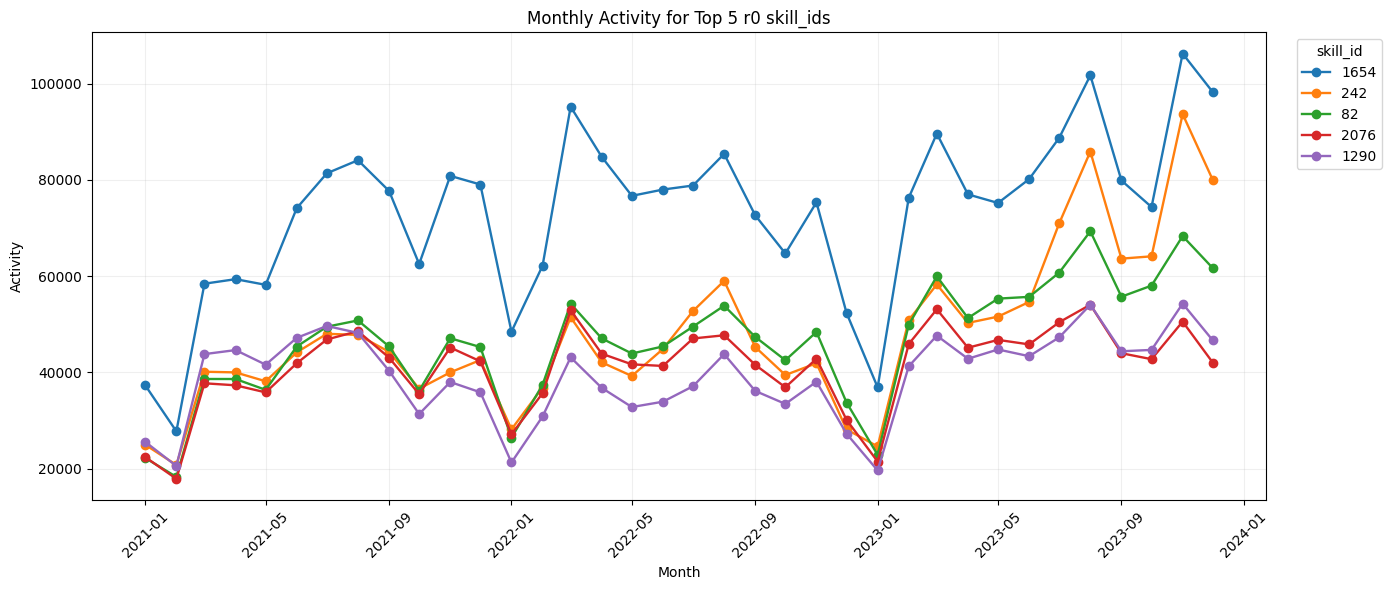

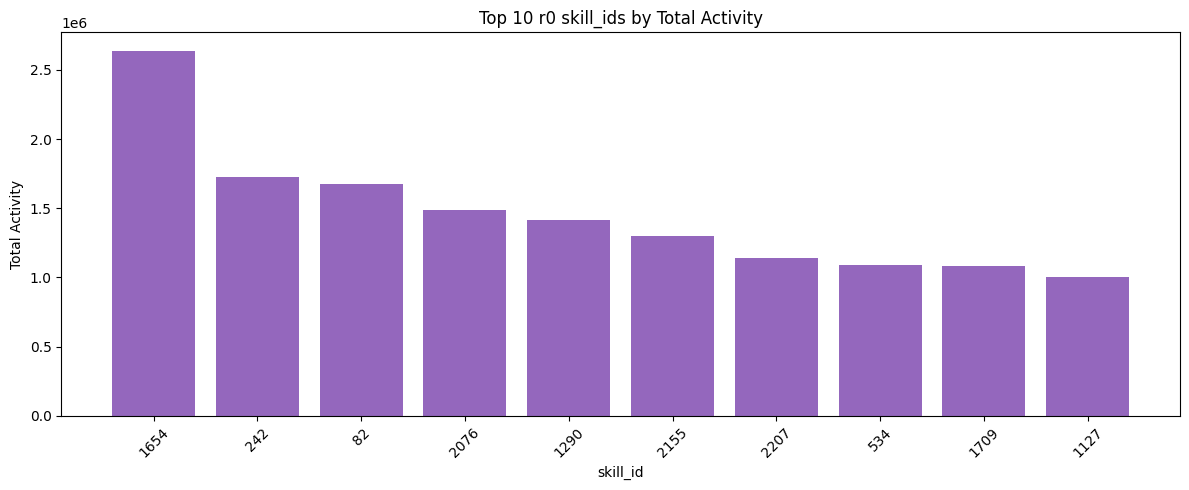

In [20]:
# Differentiate r0 activity by skill_id
r0_month_cols = [col for col in df_r0.columns if col not in ['r0_id', 'skill_id']]
r0_monthly = df_r0.groupby('skill_id')[r0_month_cols].sum()
r0_totals = r0_monthly.sum(axis=1).sort_values(ascending=False)

# Use the top skills for clearer visualization
r0_top_n_line = 5
r0_top_n_bar = 10
r0_top_line_skills = r0_totals.head(r0_top_n_line).index
r0_top_bar_skills = r0_totals.head(r0_top_n_bar).index

# Prepare monthly series for the top skill IDs
r0_top_line_monthly = r0_monthly.loc[r0_top_line_skills].T
r0_top_line_monthly.index = pd.to_datetime(r0_top_line_monthly.index, format='%Y-%m')
r0_top_line_monthly = r0_top_line_monthly.sort_index()

plt.figure(figsize=(14, 6))
for skill_id in r0_top_line_skills:
    plt.plot(r0_top_line_monthly.index, r0_top_line_monthly[skill_id], marker='o', linestyle='-', linewidth=1.7, label=str(skill_id))

plt.title('Monthly Activity for Top 5 r0 skill_ids')
plt.xlabel('Month')
plt.ylabel('Activity')
plt.legend(title='skill_id', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar([str(i) for i in r0_top_bar_skills], r0_totals.loc[r0_top_bar_skills].values, color='tab:purple')
plt.title('Top 10 r0 skill_ids by Total Activity')
plt.xlabel('skill_id')
plt.ylabel('Total Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()